# Question for this project
# Player A has a better batting average than Player B, so Player A should bat higher.

In [1]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path



In [2]:
data_path=Path(r"A:\Daily_challenges\day_02\source_datas")
files=list(data_path.glob("*.json"))
print("Number of Json files:",len(files))

Number of Json files: 1243


In [3]:
#Checking
with open (files[0],"r",encoding="utf-8") as f:
    match_01=json.load(f)

In [4]:
match_01.keys()

dict_keys(['meta', 'info', 'innings'])

In [5]:
match_01["info"].keys()

dict_keys(['balls_per_over', 'city', 'dates', 'event', 'gender', 'match_type', 'officials', 'outcome', 'overs', 'player_of_match', 'players', 'registry', 'season', 'team_type', 'teams', 'toss', 'venue'])

In [6]:
match_01["info"]["season"]

2017

In [7]:
match_01["innings"]

[{'team': 'Sunrisers Hyderabad',
  'overs': [{'over': 0,
    'deliveries': [{'actual_delivery': '0.1',
      'batter': 'DA Warner',
      'bowler': 'TS Mills',
      'non_striker': 'S Dhawan',
      'runs': {'batter': 0, 'extras': 0, 'total': 0}},
     {'actual_delivery': '0.2',
      'batter': 'DA Warner',
      'bowler': 'TS Mills',
      'non_striker': 'S Dhawan',
      'runs': {'batter': 0, 'extras': 0, 'total': 0}},
     {'actual_delivery': '0.3',
      'batter': 'DA Warner',
      'bowler': 'TS Mills',
      'non_striker': 'S Dhawan',
      'runs': {'batter': 4, 'extras': 0, 'total': 4}},
     {'actual_delivery': '0.4',
      'batter': 'DA Warner',
      'bowler': 'TS Mills',
      'non_striker': 'S Dhawan',
      'runs': {'batter': 0, 'extras': 0, 'total': 0}},
     {'actual_delivery': '0.5',
      'batter': 'DA Warner',
      'bowler': 'TS Mills',
      'extras': {'wides': 2},
      'non_striker': 'S Dhawan',
      'runs': {'batter': 0, 'extras': 2, 'total': 2}},
     {'actual_

In [8]:
len(match_01["innings"])

2

In [9]:
match_01["innings"][0].keys()

dict_keys(['team', 'overs', 'powerplays'])

In [10]:
match_01["innings"][0]["overs"][0]

{'over': 0,
 'deliveries': [{'actual_delivery': '0.1',
   'batter': 'DA Warner',
   'bowler': 'TS Mills',
   'non_striker': 'S Dhawan',
   'runs': {'batter': 0, 'extras': 0, 'total': 0}},
  {'actual_delivery': '0.2',
   'batter': 'DA Warner',
   'bowler': 'TS Mills',
   'non_striker': 'S Dhawan',
   'runs': {'batter': 0, 'extras': 0, 'total': 0}},
  {'actual_delivery': '0.3',
   'batter': 'DA Warner',
   'bowler': 'TS Mills',
   'non_striker': 'S Dhawan',
   'runs': {'batter': 4, 'extras': 0, 'total': 4}},
  {'actual_delivery': '0.4',
   'batter': 'DA Warner',
   'bowler': 'TS Mills',
   'non_striker': 'S Dhawan',
   'runs': {'batter': 0, 'extras': 0, 'total': 0}},
  {'actual_delivery': '0.5',
   'batter': 'DA Warner',
   'bowler': 'TS Mills',
   'extras': {'wides': 2},
   'non_striker': 'S Dhawan',
   'runs': {'batter': 0, 'extras': 2, 'total': 2}},
  {'actual_delivery': '0.5',
   'batter': 'S Dhawan',
   'bowler': 'TS Mills',
   'non_striker': 'DA Warner',
   'runs': {'batter': 0, 'e

In [11]:
match_01["innings"][0]["overs"][0]["deliveries"]

[{'actual_delivery': '0.1',
  'batter': 'DA Warner',
  'bowler': 'TS Mills',
  'non_striker': 'S Dhawan',
  'runs': {'batter': 0, 'extras': 0, 'total': 0}},
 {'actual_delivery': '0.2',
  'batter': 'DA Warner',
  'bowler': 'TS Mills',
  'non_striker': 'S Dhawan',
  'runs': {'batter': 0, 'extras': 0, 'total': 0}},
 {'actual_delivery': '0.3',
  'batter': 'DA Warner',
  'bowler': 'TS Mills',
  'non_striker': 'S Dhawan',
  'runs': {'batter': 4, 'extras': 0, 'total': 4}},
 {'actual_delivery': '0.4',
  'batter': 'DA Warner',
  'bowler': 'TS Mills',
  'non_striker': 'S Dhawan',
  'runs': {'batter': 0, 'extras': 0, 'total': 0}},
 {'actual_delivery': '0.5',
  'batter': 'DA Warner',
  'bowler': 'TS Mills',
  'extras': {'wides': 2},
  'non_striker': 'S Dhawan',
  'runs': {'batter': 0, 'extras': 2, 'total': 2}},
 {'actual_delivery': '0.5',
  'batter': 'S Dhawan',
  'bowler': 'TS Mills',
  'non_striker': 'DA Warner',
  'runs': {'batter': 0, 'extras': 0, 'total': 0}},
 {'actual_delivery': '0.6',
  'b

In [12]:
match_01["innings"][0]["overs"][0]["deliveries"][0]

{'actual_delivery': '0.1',
 'batter': 'DA Warner',
 'bowler': 'TS Mills',
 'non_striker': 'S Dhawan',
 'runs': {'batter': 0, 'extras': 0, 'total': 0}}

In [13]:
delivery=match_01["innings"][0]["overs"][1]["deliveries"][4]
print(delivery.get("wickets"))

[{'kind': 'caught', 'player_out': 'DA Warner', 'fielders': [{'name': 'Mandeep Singh'}]}]


In [14]:
def extract_batting_data(file_path):

    with open(file_path, "r", encoding="utf-8") as f:
        match = json.load(f)

    match_id = file_path.stem
    season = str(match["info"]["season"])

    rows = []

    for innings_number, innings in enumerate(match["innings"], start=1):

        batting_team = innings["team"]

        for over in innings.get("overs", []):

            for delivery in over["deliveries"]:

                batter = delivery["batter"]

                runs = delivery["runs"]["batter"]

                extras = delivery.get("extras", {})

               
                ball_faced = int(
                    "wides" not in extras
                    and "noballs" not in extras
                )

                dismissed_player = None 
                dismissal_kind = None

                wickets = delivery.get("wickets", [])

                for wicket in wickets:

                    player_out = wicket["player_out"]
                    kind = wicket["kind"]

                    
                    if player_out == batter:
                        dismissed_player = player_out
                        dismissal_kind = kind

                rows.append({
                    "match_id": match_id,
                    "season": season,
                    "innings": innings_number,
                    "batting_team": batting_team,
                    "batter": batter,
                    "runs": runs,
                    "ball_faced": ball_faced,
                    "dismissed_player": dismissed_player,
                    "dismissal_kind": dismissal_kind
                })

    return pd.DataFrame(rows)

In [15]:
test_df=extract_batting_data(files[0])
test_df.head(25)

,match_id,season,innings,batting_team,batter,runs,ball_faced,dismissed_player,dismissal_kind
0,1082591,2017,1,Sunrisers Hyderabad,DA Warner,0,1,NaN,NaN
1,1082591,2017,1,Sunrisers Hyderabad,DA Warner,0,1,NaN,NaN
2,1082591,2017,1,Sunrisers Hyderabad,DA Warner,4,1,NaN,NaN
3,1082591,2017,1,Sunrisers Hyderabad,DA Warner,0,1,NaN,NaN
4,1082591,2017,1,Sunrisers Hyderabad,DA Warner,0,0,NaN,NaN
5,1082591,2017,1,Sunrisers Hyderabad,S Dhawan,0,1,NaN,NaN
6,1082591,2017,1,Sunrisers Hyderabad,S Dhawan,0,1,NaN,NaN
7,1082591,2017,1,Sunrisers Hyderabad,S Dhawan,1,1,NaN,NaN
8,1082591,2017,1,Sunrisers Hyderabad,DA Warner,4,1,NaN,NaN
9,1082591,2017,1,Sunrisers Hyderabad,DA Warner,0,0,NaN,NaN


In [16]:
test_df.shape

(248, 9)

In [17]:
test_df.columns

Index(['match_id', 'season', 'innings', 'batting_team', 'batter', 'runs',
       'ball_faced', 'dismissed_player', 'dismissal_kind'],
      dtype='str')

In [18]:
print(test_df["runs"].sum())

366


In [19]:
print(test_df["batter"].nunique())

17


In [20]:
all_matches = []

for i, file in enumerate(files):

    df = extract_batting_data(file)

    all_matches.append(df)

    if (i + 1) % 100 == 0:
        print(f"Processed {i + 1} matches")

Processed 100 matches
Processed 200 matches
Processed 300 matches
Processed 400 matches
Processed 500 matches
Processed 600 matches
Processed 700 matches
Processed 800 matches
Processed 900 matches
Processed 1000 matches
Processed 1100 matches
Processed 1200 matches


In [21]:
batting_data = pd.concat(
    all_matches,
    ignore_index=True
)

In [22]:
batting_data.shape

(295732, 9)

In [23]:
batting_data.head()

,match_id,season,innings,batting_team,batter,runs,ball_faced,dismissed_player,dismissal_kind
0,1082591,2017,1,Sunrisers Hyderabad,DA Warner,0,1,NaN,NaN
1,1082591,2017,1,Sunrisers Hyderabad,DA Warner,0,1,NaN,NaN
2,1082591,2017,1,Sunrisers Hyderabad,DA Warner,4,1,NaN,NaN
3,1082591,2017,1,Sunrisers Hyderabad,DA Warner,0,1,NaN,NaN
4,1082591,2017,1,Sunrisers Hyderabad,DA Warner,0,0,NaN,NaN


In [24]:
batting_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 295732 entries, 0 to 295731
Data columns (total 9 columns):
 #   Column            Non-Null Count   Dtype
---  ------            --------------   -----
 0   match_id          295732 non-null  str  
 1   season            295732 non-null  str  
 2   innings           295732 non-null  int64
 3   batting_team      295732 non-null  str  
 4   batter            295732 non-null  str  
 5   runs              295732 non-null  int64
 6   ball_faced        295732 non-null  int64
 7   dismissed_player  14134 non-null   str  
 8   dismissal_kind    14134 non-null   str  
dtypes: int64(3), str(6)
memory usage: 20.3 MB


In [25]:
ipl_2024=batting_data[
    batting_data["season"]=="2024"].copy()

In [26]:
ipl_2024.shape

(17103, 9)

In [27]:
ipl_2024["match_id"].nunique()

71

In [28]:
player_totals = (
    ipl_2024
    .groupby("batter")
    .agg(
        runs=("runs", "sum"),
        balls=("ball_faced", "sum")
    )
    .reset_index()
)

In [29]:
dismissals = (
    ipl_2024[
        ipl_2024["dismissed_player"].notna()
    ]
    .groupby("dismissed_player")
    .size()
    .reset_index(name="dismissals")
)

In [30]:
dismissals = dismissals.rename(
    columns={
        "dismissed_player": "batter"
    }
)

In [31]:
player_totals = player_totals.merge(
    dismissals,
    on="batter",
    how="left"
)

In [32]:
player_totals["dismissals"] = (
    player_totals["dismissals"]
    .fillna(0)
)

In [33]:
dismissals.head()

,batter,dismissals
0,A Badoni,8
1,A Manohar,2
2,A Nortje,2
3,A Raghuvanshi,7
4,AA Kulkarni,2


In [34]:
player_totals["Batting_average"]=np.where(
    player_totals["dismissals"]>0,
    player_totals["runs"]/player_totals["dismissals"],
    np.nan
)

In [35]:
player_totals["strike_rate"]=(
    player_totals["runs"]/player_totals["balls"]
)*100

In [36]:
qualified_players=player_totals[
    player_totals["balls"]>=100
].copy()

In [37]:
player_match=(
    ipl_2024.groupby(["match_id","batter"])
.agg(
    runs=("runs","sum"),
    balls=("ball_faced","sum")
)
.reset_index()
)
player_match

,match_id,batter,runs,balls
0,1422119,AM Rahane,27,19
1,1422119,Anuj Rawat,48,25
2,1422119,C Green,18,22
3,1422119,DJ Mitchell,22,18
4,1422119,F du Plessis,35,23
...,...,...,...,...
1110,1426312,SP Narine,6,2
1111,1426312,SS Iyer,6,3
1112,1426312,Shahbaz Ahmed,8,7
1113,1426312,TM Head,0,1


In [38]:
match_stats=(
    player_match.groupby("batter")["runs"].agg(
        mean="mean"
    )
    .reset_index()
)

In [39]:
median_stats = (
    player_match
    .groupby("batter")["runs"]
    .agg(
        median="median"
    )
    .reset_index()
)

In [40]:
std_stats = (
    player_match
    .groupby("batter")["runs"]
    .agg(
        std="std"
    )
    .reset_index()
)

In [41]:
consistency = (
    player_match
    .groupby("batter")["runs"]
    .agg(
        mean="mean",
        median="median",
        std="std"
    )
    .reset_index()
)

In [42]:
final_stats = player_totals.merge(
    consistency,
    on="batter",
    how="left"
)

In [43]:
final_stats.head()

,batter,runs,balls,dismissals,Batting_average,strike_rate,mean,median,std
0,A Badoni,235,171,8.0,29.375000,137.426901,19.583333,16.5,18.729939
1,A Kamboj,2,2,0.0,NaN,100.000000,2.000000,2.0,NaN
2,A Manohar,9,16,2.0,4.500000,56.250000,4.500000,4.5,4.949747
3,A Nortje,4,8,2.0,2.000000,50.000000,2.000000,2.0,2.828427
4,A Raghuvanshi,163,105,7.0,23.285714,155.238095,23.285714,24.0,17.547215


In [44]:
boundary_stats = (
    ipl_2024
    .groupby("batter")["runs"]
    .agg(
        fours=lambda x: (x == 4).sum(),
        sixes=lambda x: (x == 6).sum()
    )
    .reset_index()
)

In [45]:
final_stats = final_stats.merge(
    boundary_stats,
    on="batter",
    how="left"
)

In [46]:
final_stats["boundary_runs"] = (
    final_stats["fours"] * 4
    + final_stats["sixes"] * 6
)

In [47]:
final_stats["boundary_percentage"] = (
    final_stats["boundary_runs"]
    / final_stats["runs"]
) * 100

In [48]:
final_stats[
    final_stats["balls"] >= 200
].sort_values(
    "Batting_average",
    ascending=False
).head(20)

,batter,runs,balls,dismissals,Batting_average,strike_rate,mean,median,std,fours,sixes,boundary_runs,boundary_percentage
90,N Pooran,499,279,8.0,62.375000,178.853047,35.642857,37.0,22.318006,35,36,356,71.342685
160,V Kohli,741,479,12.0,61.750000,154.697286,49.400000,42.0,31.350097,62,38,476,64.237517
113,RD Gaikwad,583,412,11.0,53.000000,141.504854,41.642857,37.0,35.278250,58,18,340,58.319039
104,R Parag,573,383,11.0,52.090909,149.608355,40.928571,39.5,25.637905,40,33,358,62.478185
145,Shashank Singh,354,215,7.0,50.571429,164.651163,25.285714,23.0,22.506165,28,21,238,67.231638
139,SV Samson,531,343,11.0,48.272727,154.810496,35.400000,18.0,30.434473,48,24,336,63.276836
27,B Sai Sudharsan,527,368,11.0,47.909091,143.206522,43.916667,36.0,27.929972,48,17,294,55.787476
164,VR Iyer,370,233,8.0,46.250000,158.798283,28.461538,26.0,23.343862,35,19,254,68.648649
158,Tilak Varma,416,277,10.0,41.600000,150.180505,32.000000,32.0,21.397040,35,19,254,61.057692
120,RR Pant,446,287,11.0,40.545455,155.400697,34.307692,29.0,22.238797,36,25,294,65.919283


In [49]:
players = ["PLAYER A", "PLAYER B"]

comparison = final_stats[
    final_stats["batter"].isin(players)
].copy()

In [50]:
print(comparison.shape)
print(comparison.columns)

display(comparison[[
    "batter",
    "runs",
    "Batting_average",
    "strike_rate"
]].sort_values("runs", ascending=False).head(20))

(0, 13)
Index(['batter', 'runs', 'balls', 'dismissals', 'Batting_average',
       'strike_rate', 'mean', 'median', 'std', 'fours', 'sixes',
       'boundary_runs', 'boundary_percentage'],
      dtype='str')


,batter,runs,Batting_average,strike_rate


In [51]:
print(comparison[[
    "runs",
    "Batting_average",
    "strike_rate"
]].describe())

       runs  Batting_average  strike_rate
count   0.0              0.0          0.0
mean    NaN              NaN          NaN
std     NaN              NaN          NaN
min     NaN              NaN          NaN
25%     NaN              NaN          NaN
50%     NaN              NaN          NaN
75%     NaN              NaN          NaN
max     NaN              NaN          NaN


In [52]:
print(comparison[
    (comparison["Batting_average"] <= 0) |
    (comparison["strike_rate"] <= 0) |
    (comparison["runs"] <= 0)
])

Empty DataFrame
Columns: [batter, runs, balls, dismissals, Batting_average, strike_rate, mean, median, std, fours, sixes, boundary_runs, boundary_percentage]
Index: []


In [53]:
print(comparison.isna().sum())

batter                 0
runs                   0
balls                  0
dismissals             0
Batting_average        0
strike_rate            0
mean                   0
median                 0
std                    0
fours                  0
sixes                  0
boundary_runs          0
boundary_percentage    0
dtype: int64


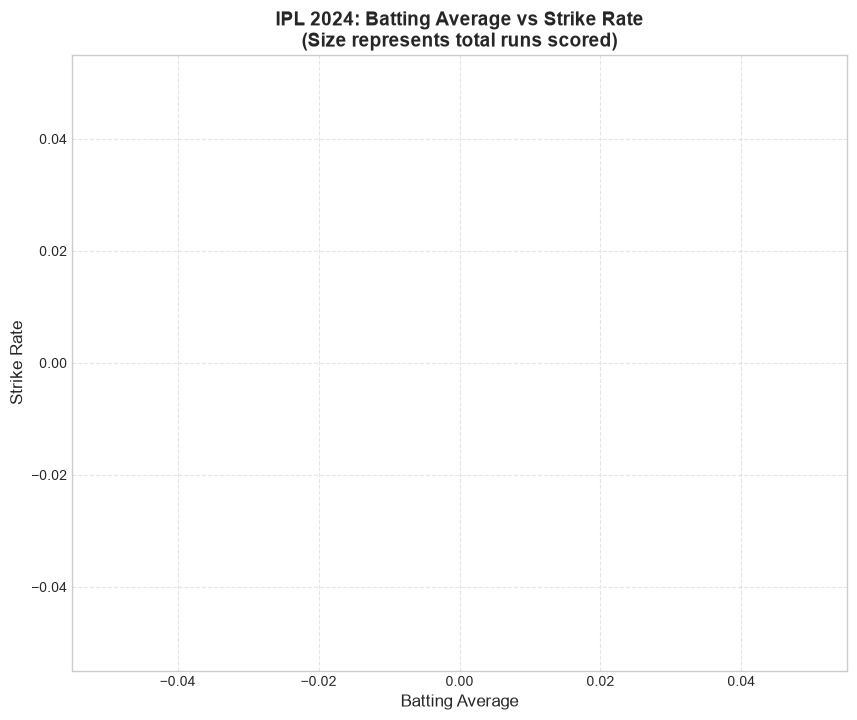

In [54]:
import matplotlib.pyplot as plt


plt.figure(figsize=(10, 8)) 
plt.style.use('seaborn-v0_8-whitegrid')


plt.scatter(
    comparison["Batting_average"],
    comparison["strike_rate"],
    s=(comparison["runs"] ** 0.5) * 15, 
    alpha=0.6,                         
    color='teal'                        
)


for _, row in comparison.iterrows():
   
    if row["runs"] > 300 or row["strike_rate"] > 150:
        plt.annotate(
            row["batter"],
            (row["Batting_average"], row["strike_rate"]),
            xytext=(4, 4),              
            textcoords="offset points",
            fontsize=9
        )


plt.xlabel("Batting Average", fontsize=12)
plt.ylabel("Strike Rate", fontsize=12)
plt.title("IPL 2024: Batting Average vs Strike Rate\n(Size represents total runs scored)", fontsize=14, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.5) 

plt.show()


In [55]:

print("--- Column Names and Types ---")
print(comparison.dtypes)

print("\n--- First 3 Rows of Data ---")
print(comparison[["Batting_average", "strike_rate", "runs"]].head(3))


--- Column Names and Types ---
batter                     str
runs                     int64
balls                    int64
dismissals             float64
Batting_average        float64
strike_rate            float64
mean                   float64
median                 float64
std                    float64
fours                    int64
sixes                    int64
boundary_runs            int64
boundary_percentage    float64
dtype: object

--- First 3 Rows of Data ---
Empty DataFrame
Columns: [Batting_average, strike_rate, runs]
Index: []


In [56]:

print("Total players before filtering:", len(player_totals)) 



Total players before filtering: 171


In [57]:

print("Total players after filtering/merging:", len(comparison))


Total players after filtering/merging: 0


In [58]:
print("batting_stats shape:", batting_data.shape)
display(batting_data.head())

batting_stats shape: (295732, 9)


,match_id,season,innings,batting_team,batter,runs,ball_faced,dismissed_player,dismissal_kind
0,1082591,2017,1,Sunrisers Hyderabad,DA Warner,0,1,NaN,NaN
1,1082591,2017,1,Sunrisers Hyderabad,DA Warner,0,1,NaN,NaN
2,1082591,2017,1,Sunrisers Hyderabad,DA Warner,4,1,NaN,NaN
3,1082591,2017,1,Sunrisers Hyderabad,DA Warner,0,1,NaN,NaN
4,1082591,2017,1,Sunrisers Hyderabad,DA Warner,0,0,NaN,NaN


In [59]:
print(batting_data["runs"].describe())

count    295732.000000
mean          1.290117
std           1.664418
min           0.000000
25%           0.000000
50%           1.000000
75%           1.000000
max           6.000000
Name: runs, dtype: float64


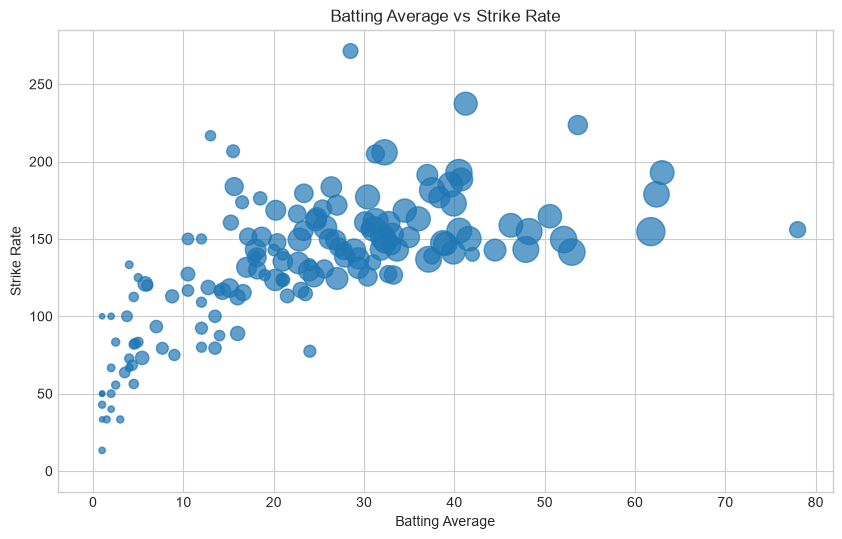

In [61]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.scatter(
    final_stats["Batting_average"],
    final_stats["strike_rate"],
    s=(final_stats["runs"] ** 0.5) * 15,
    alpha=0.7
)

plt.xlabel("Batting Average")
plt.ylabel("Strike Rate")
plt.title("Batting Average vs Strike Rate")

plt.show()

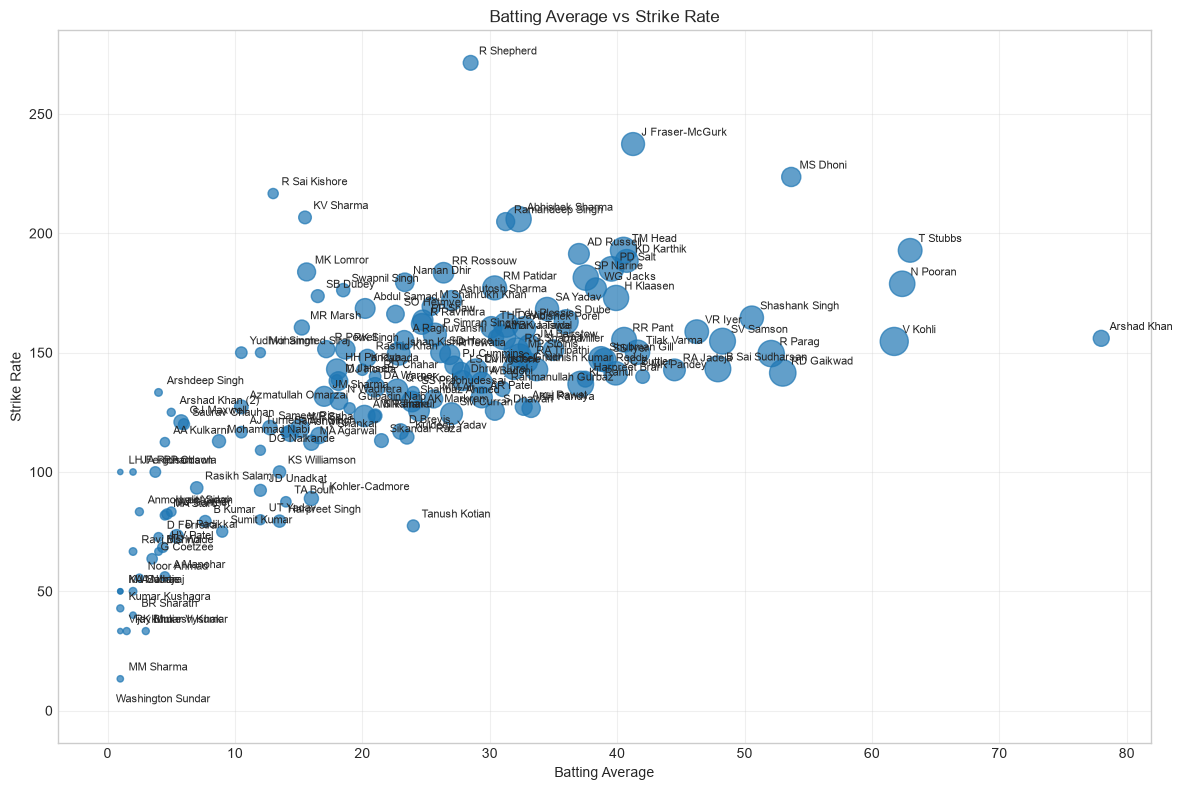

In [62]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))

plt.scatter(
    final_stats["Batting_average"],
    final_stats["strike_rate"],
    s=(final_stats["runs"] ** 0.5) * 15,
    alpha=0.7
)


for _, row in final_stats.iterrows():
    plt.annotate(
        row["batter"],
        (row["Batting_average"], row["strike_rate"]),
        xytext=(6, 6),
        textcoords="offset points",
        fontsize=8
    )

plt.xlabel("Batting Average")
plt.ylabel("Strike Rate")
plt.title("Batting Average vs Strike Rate")

plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

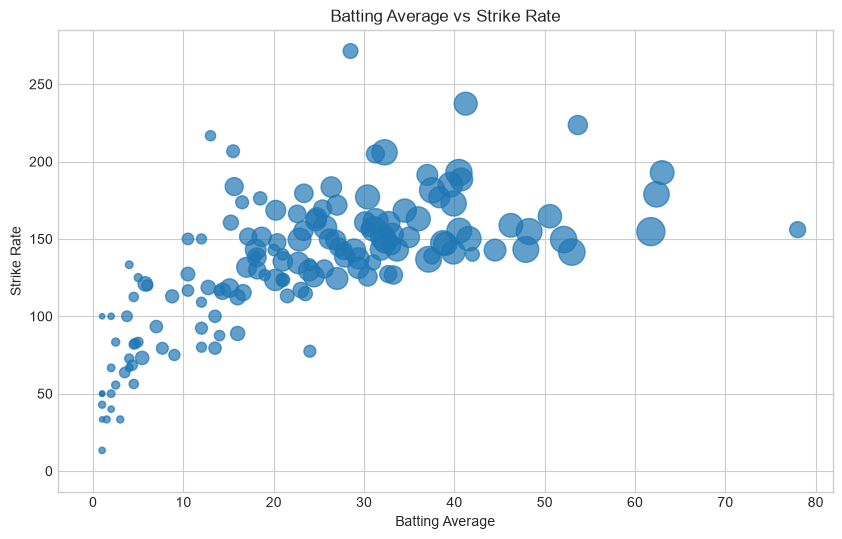

In [63]:
scatter_data = final_stats.dropna(
    subset=["Batting_average", "strike_rate"]
).copy()

plt.figure(figsize=(10, 6))

plt.scatter(
    scatter_data["Batting_average"],
    scatter_data["strike_rate"],
    s=(scatter_data["runs"] ** 0.5) * 15,
    alpha=0.7
)


plt.xlabel("Batting Average")
plt.ylabel("Strike Rate")
plt.title("Batting Average vs Strike Rate")

plt.show()

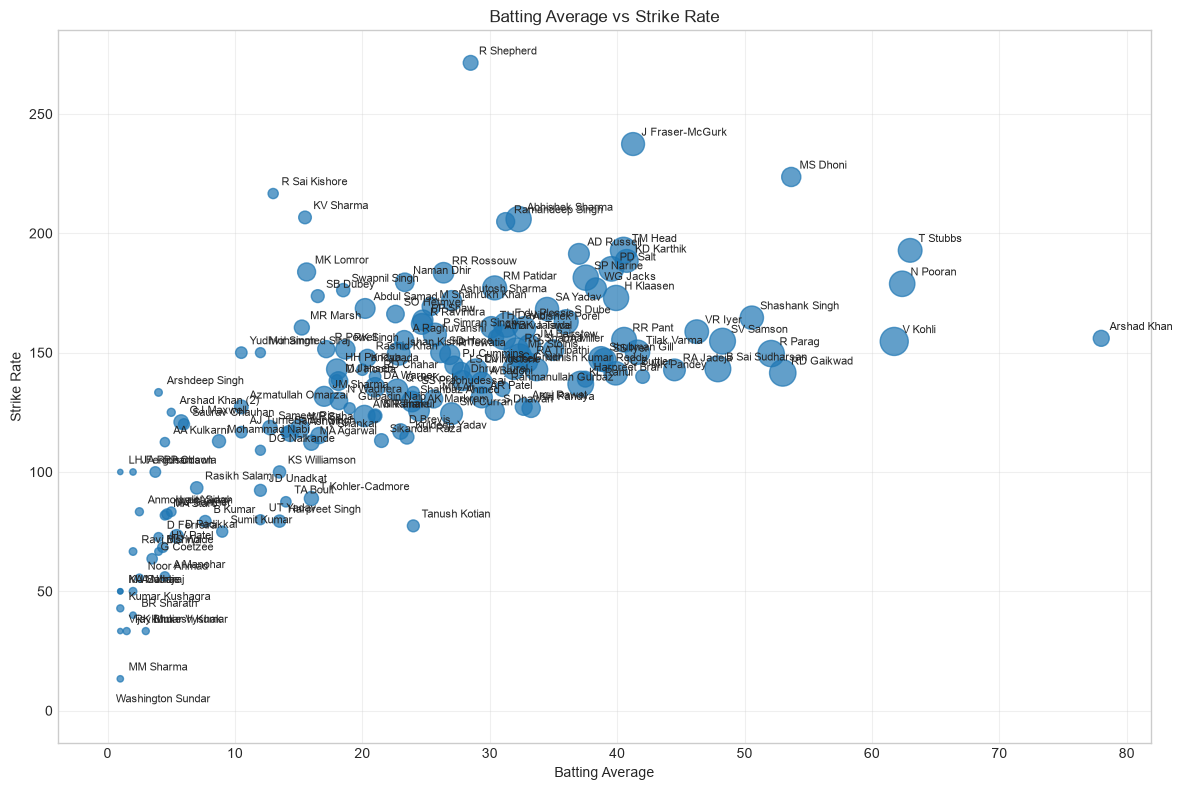

In [64]:
import matplotlib.pyplot as plt

scatter_data = final_stats.dropna(
    subset=["Batting_average", "strike_rate"]
).copy()

plt.figure(figsize=(12, 8))

plt.scatter(
    scatter_data["Batting_average"],
    scatter_data["strike_rate"],
    s=(scatter_data["runs"] ** 0.5) * 15,
    alpha=0.7
)


for _, row in scatter_data.iterrows():
    plt.annotate(
        row["batter"],
        (row["Batting_average"], row["strike_rate"]),
        xytext=(6, 6),
        textcoords="offset points",
        fontsize=8
    )

plt.xlabel("Batting Average")
plt.ylabel("Strike Rate")
plt.title("Batting Average vs Strike Rate")

plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

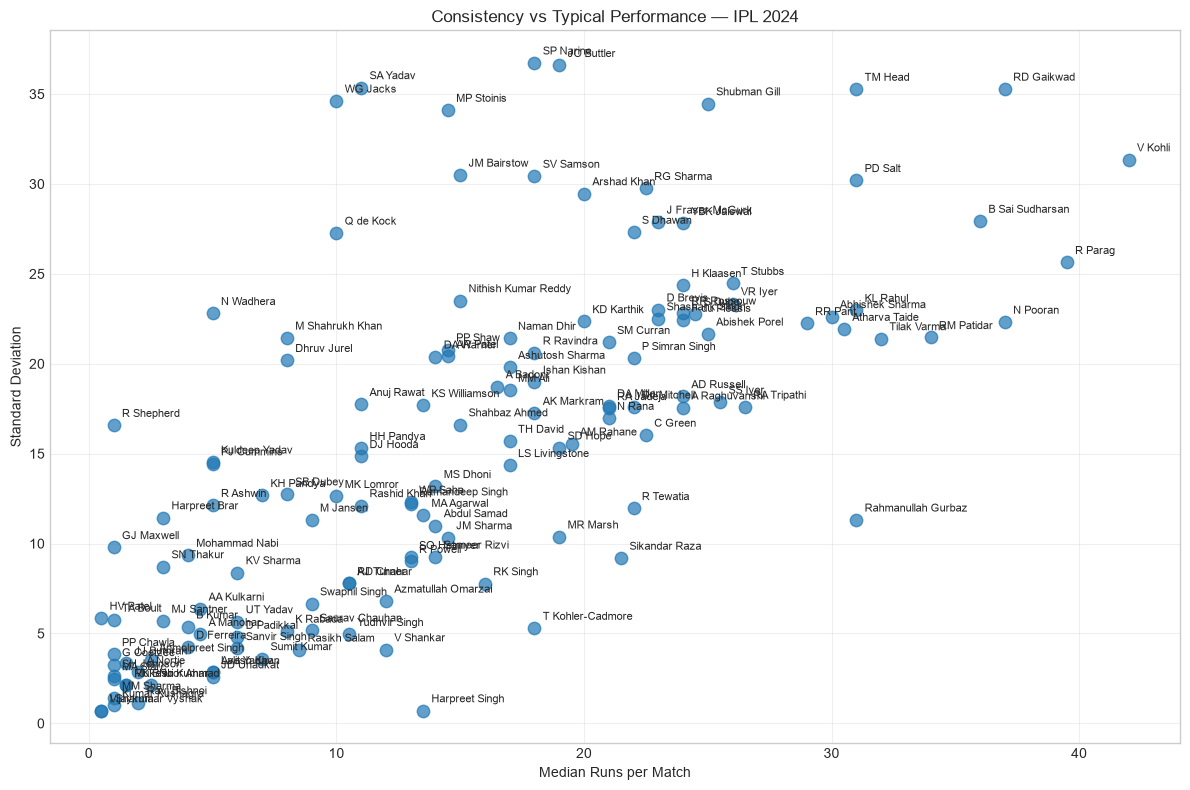

In [65]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))

plt.scatter(
    final_stats["median"],
    final_stats["std"],
    s=80,
    alpha=0.7
)

for _, row in final_stats.iterrows():
    plt.annotate(
        row["batter"],
        (row["median"], row["std"]),
        xytext=(6, 6),
        textcoords="offset points",
        fontsize=8
    )

plt.xlabel("Median Runs per Match")
plt.ylabel("Standard Deviation")
plt.title("Consistency vs Typical Performance — IPL 2024")

plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()